In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('/content/all_stocks_5yr.csv')

In [3]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


Open - price of the stock at market open (this is NYSE data so all in USD)

High - Highest price reached in the day

Low - Lowest price reached in the day

Close - price of the stock at market close

Volume - Number of shares traded

Name - the stock's ticker name

In [4]:
df.isnull().sum()

,0
date,0
open,11
high,8
low,8
close,0
volume,0
Name,0


In [5]:
# 각 행에 null 값이 있는지 확인하고, null 값이 있는 행의 개수를 계산
rows_with_null = df.isnull().any(axis=1).sum()
print(f"null 값을 포함하는 행의 개수: {rows_with_null}")

null 값을 포함하는 행의 개수: 11


In [6]:
#행의 개수가 많지 않으므로 행들을 삭제하고 명시적으로 복사본을 만듭니다.
df_dropna = df.dropna(axis=0, how='any').copy()
# 시간순으로 데이터 재배치
df_dropna = df.sort_values('date')

df_dropna.tail()

,date,open,high,low,close,volume,Name
147509,2018-02-07,53.38,54.36,52.94,52.97,6496219,CSX
31474,2018-02-07,107.46,109.48,106.56,106.63,1668253,ALB
241494,2018-02-07,10.75,11.04,10.70,10.76,68041787,F
42609,2018-02-07,176.25,180.99,176.00,177.47,5715671,AMGN
619039,2018-02-07,72.70,75.00,72.69,73.86,4534912,ZTS


In [7]:
df_dropna.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [8]:
df_dropna.columns
df_dropna.info()
df_dropna.shape

<class 'pandas.core.frame.DataFrame'>
Index: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 37.8+ MB


(619040, 7)

# 일일 변동폭


In [9]:
# range column과 change column 추가
df_dropna['range'] = df_dropna['high'] - df_dropna['low']
df_dropna['change'] = df_dropna['close'] - df_dropna['open']
df_dropna.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'range',
       'change'],
      dtype='object')

<Axes: xlabel='date'>

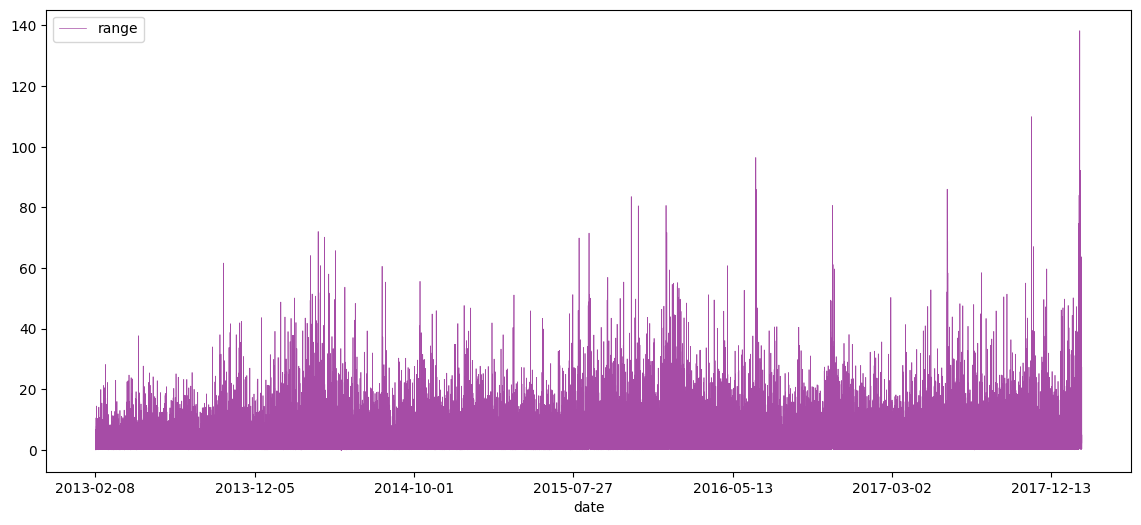

In [24]:
df_dropna.plot(
    x='date',
    y=[ 'range'],
    figsize=(14,6),
    style=['-'],
    color= 'purple',
    linewidth='0.5',
    alpha=0.7
)

평균적으로 변동성이 큰 상위 10개 종목

In [28]:
df_dropna.groupby('Name')['range'].mean().sort_values(ascending=False)


,range
Name,
PCLN,23.530972
REGN,11.627797
GOOG,11.365405
AMZN,10.903705
GOOGL,10.670986
...,...
PBCT,0.256123
F,0.254865
RF,0.237236


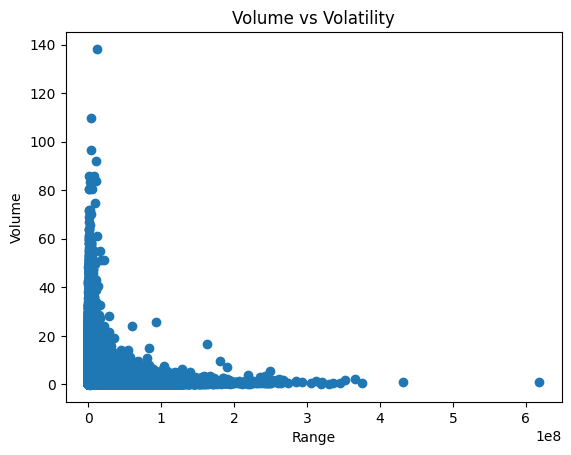

In [31]:
plt.scatter(df_dropna['volume'], df_dropna['range'])
plt.xlabel('Range')
plt.ylabel('Volume')
plt.title('Volume vs Volatility')
plt.show()

변동폭을 기준으로 거래량을 분석한 결과, 변동성이 낮은 구간에서 다양한 거래량이 분포하는 반면, 변동성이 매우 높은 구간에서는 거래량이 제한적으로 나타나는 경향이 확인되었다.

#시초가 기준 주가 흐름

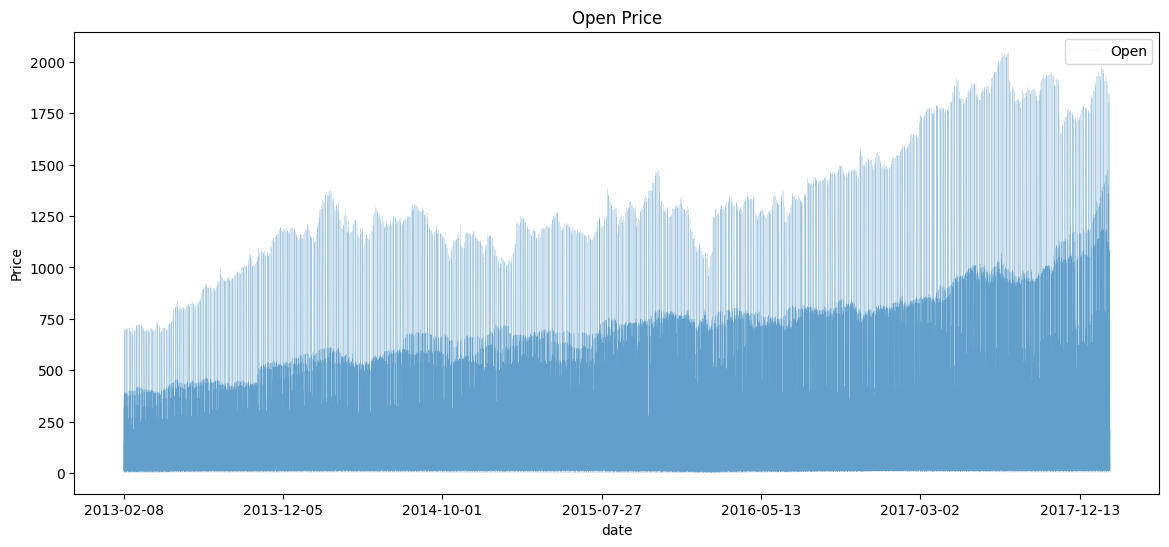

In [10]:
df_dropna.plot(
    x='date',
    y=[ 'open'],
    kind='line',
    figsize=(14,6),
    style=['-'],
    linewidth=0.1,
    alpha=0.7

)

plt.title('Open Price')
plt.ylabel('Price')
plt.legend(['Open'])
plt.show()

시초가가 높았던 날짜 10개

In [11]:
df_dropna.nlargest(10, 'open')

,date,open,high,low,close,volume,Name,range,change
441193,2017-08-08,2044.00,2067.99,2035.11,2049.00,830572,PCLN,32.88,5.00
441188,2017-08-01,2040.09,2041.49,2017.01,2024.59,371412,PCLN,24.48,-15.50
441185,2017-07-27,2040.05,2043.95,1996.00,2025.09,487467,PCLN,47.95,-14.96
441192,2017-08-07,2034.73,2044.51,2022.00,2042.64,402270,PCLN,22.51,7.91
441191,2017-08-04,2031.02,2035.47,2020.29,2032.77,333534,PCLN,15.18,1.75
441187,2017-07-31,2030.00,2033.00,2010.24,2028.50,503331,PCLN,22.76,-1.50
441186,2017-07-28,2026.47,2040.63,2007.97,2024.06,505472,PCLN,32.66,-2.41
441189,2017-08-02,2023.45,2025.50,2000.00,2021.37,354292,PCLN,25.50,-2.08
441190,2017-08-03,2020.97,2030.00,2012.55,2027.98,430926,PCLN,17.45,7.01
441184,2017-07-26,2019.24,2037.00,2017.56,2033.21,311753,PCLN,19.44,13.97


시초가가 낮았던 날짜 10개

In [12]:
df_dropna.nsmallest(10, 'open')

,date,open,high,low,close,volume,Name,range,change
39453,2015-07-28,1.62,1.77,1.62,1.77,14614569,AMD,0.15,0.15
115058,2016-02-11,1.66,1.81,1.53,1.78,50804186,CHK,0.28,0.12
39452,2015-07-27,1.67,1.70,1.61,1.62,11916468,AMD,0.09,-0.05
39497,2015-09-29,1.67,1.69,1.65,1.67,7005323,AMD,0.04,0.00
39471,2015-08-21,1.68,1.80,1.68,1.78,12529458,AMD,0.12,0.10
39494,2015-09-24,1.68,1.73,1.66,1.72,11247701,AMD,0.07,0.04
115060,2016-02-16,1.68,1.91,1.65,1.86,39305372,CHK,0.26,0.18
39472,2015-08-24,1.69,1.83,1.65,1.75,17217369,AMD,0.18,0.06
39474,2015-08-26,1.69,1.73,1.66,1.72,10715268,AMD,0.07,0.03
39496,2015-09-28,1.69,1.70,1.66,1.66,5693063,AMD,0.04,-0.03


#종가 기준 주가 흐름

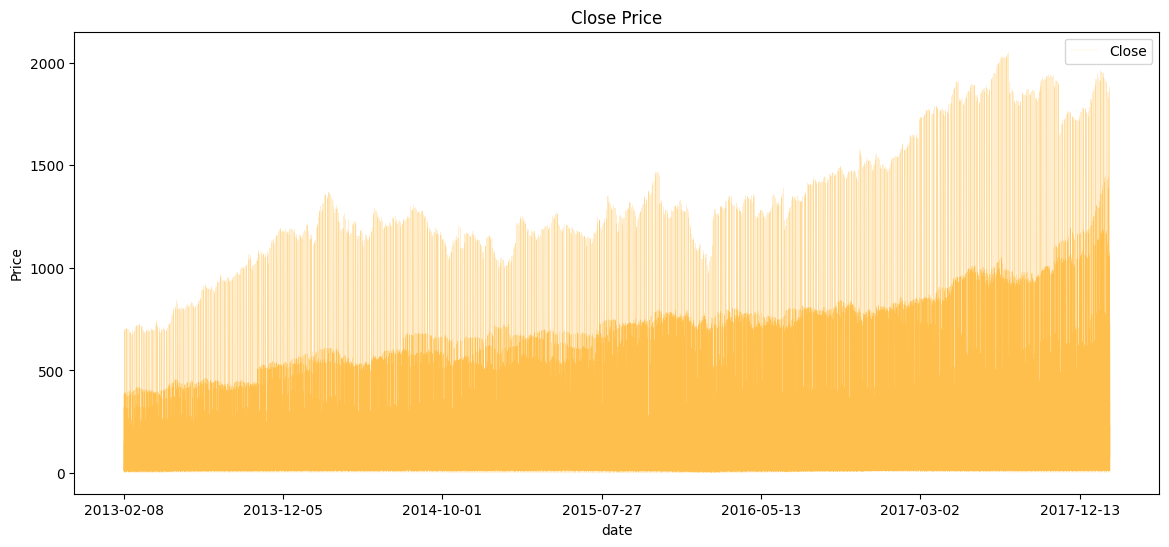

In [13]:
df_dropna.plot(
    x='date',
    y=[ 'close'],
    figsize=(14,6),
    style=['-'],
    color= 'orange',
    linewidth='0.1',
    alpha=0.7
)

plt.title('Close Price')
plt.ylabel('Price')
plt.legend(['Close'])
plt.show()

In [14]:
df_dropna.nlargest(10, 'close')

,date,open,high,low,close,volume,Name,range,change
441193,2017-08-08,2044.00,2067.99,2035.11,2049.00,830572,PCLN,32.88,5.00
441192,2017-08-07,2034.73,2044.51,2022.00,2042.64,402270,PCLN,22.51,7.91
441184,2017-07-26,2019.24,2037.00,2017.56,2033.21,311753,PCLN,19.44,13.97
441191,2017-08-04,2031.02,2035.47,2020.29,2032.77,333534,PCLN,15.18,1.75
441187,2017-07-31,2030.00,2033.00,2010.24,2028.50,503331,PCLN,22.76,-1.50
441190,2017-08-03,2020.97,2030.00,2012.55,2027.98,430926,PCLN,17.45,7.01
441185,2017-07-27,2040.05,2043.95,1996.00,2025.09,487467,PCLN,47.95,-14.96
441188,2017-08-01,2040.09,2041.49,2017.01,2024.59,371412,PCLN,24.48,-15.50
441186,2017-07-28,2026.47,2040.63,2007.97,2024.06,505472,PCLN,32.66,-2.41
441189,2017-08-02,2023.45,2025.50,2000.00,2021.37,354292,PCLN,25.50,-2.08


In [15]:
df_dropna.nsmallest(10, 'close')

,date,open,high,low,close,volume,Name,range,change
115059,2016-02-12,1.86,1.890,1.56,1.59,49579181,CHK,0.330,-0.27
39452,2015-07-27,1.67,1.700,1.61,1.62,11916468,AMD,0.090,-0.05
39473,2015-08-25,1.82,1.820,1.66,1.66,12097696,AMD,0.160,-0.16
39496,2015-09-28,1.69,1.700,1.66,1.66,5693063,AMD,0.040,-0.03
39451,2015-07-24,1.76,1.770,1.65,1.67,16478376,AMD,0.120,-0.09
39497,2015-09-29,1.67,1.690,1.65,1.67,7005323,AMD,0.040,0.00
39470,2015-08-20,1.79,1.800,1.70,1.70,13745659,AMD,0.100,-0.09
39493,2015-09-23,1.76,1.775,1.69,1.70,9649200,AMD,0.085,-0.06
115057,2016-02-10,1.99,2.005,1.63,1.70,32507974,CHK,0.375,-0.29
39478,2015-09-01,1.77,1.820,1.71,1.71,8470710,AMD,0.110,-0.06


#상승, 하락장 분석

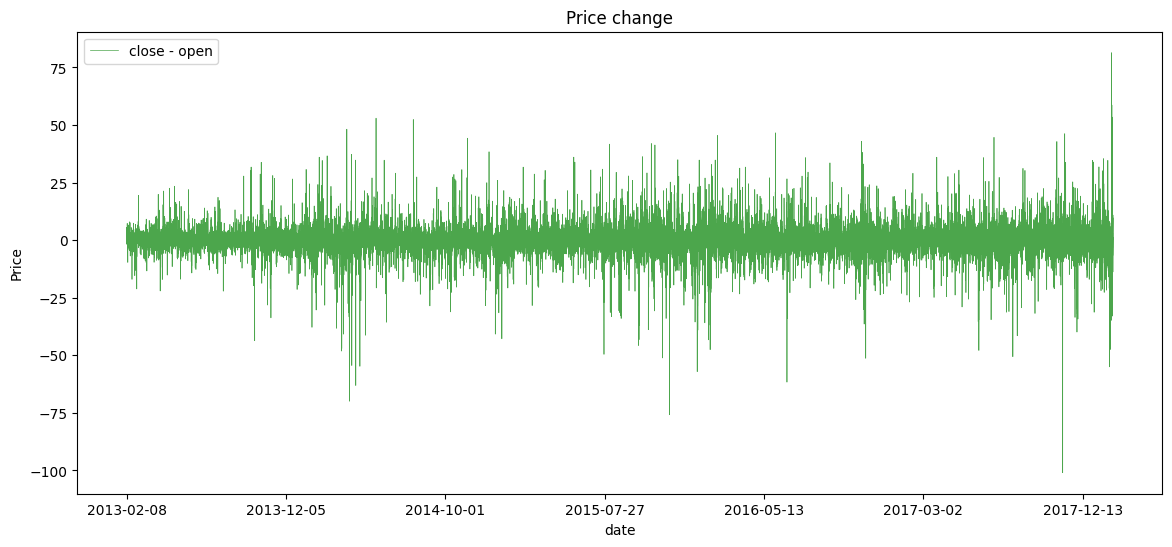

In [18]:
df_dropna.plot(
    x='date',
    y=[ 'change'],
    figsize=(14,6),
    style=['-'],
    color= 'green',
    linewidth='0.5',
    alpha=0.7
)
plt.title('Price change')
plt.ylabel('Price')
plt.legend(['close - open'])
plt.show()

상승장 분석

In [ ]:
# 상승장 일자 출력
print(
    df_dropna[df_dropna['change'] > 0]
    .sort_values('change', ascending=False)[['date', 'change']]
)

print(
    "총일수:",
    (df_dropna['change'] > 0).sum()
)

              date   change
47644   2018-02-06  81.3800
441318  2018-02-06  58.6500
252540  2018-02-06  53.4200
440386  2014-05-27  52.9500
440434  2014-08-04  52.3700
...            ...      ...
585506  2014-08-27   0.0025
292402  2015-09-18   0.0020
433921  2013-08-29   0.0010
227580  2013-09-25   0.0010
212496  2013-10-29   0.0010

[318970 rows x 2 columns]
총일수: 318970


하락장 분석

In [ ]:
# 하락장 일자 출력
print(
    df_dropna[df_dropna['change'] < 0]
    .sort_values('change')[['date', 'change']]
)

print(
    "총일수:",
    (df_dropna['change'] < 0).sum()
)

              date    change
441257  2017-11-07 -100.9800
127593  2015-11-20  -75.8100
440351  2014-04-04  -69.9200
127190  2014-04-17  -63.0900
440911  2016-06-24  -61.6400
...            ...       ...
291923  2013-10-22   -0.0020
112127  2014-06-23   -0.0020
292276  2015-03-20   -0.0020
1337    2013-06-03   -0.0014
1516    2014-02-18   -0.0014

[295027 rows x 2 columns]
총일수: 295027


상승장일수 가 더 많음

# 거래량 많은 종목 분석


In [39]:
#상위 10개 출력
df_dropna.groupby('Name')['volume'] \
    .sum() \
    .sort_values(ascending=False) \
    .reset_index() \
    .head(10)

,Name,volume
0,BAC,117884953591
1,AAPL,68046305767
2,GE,53023644686
3,F,43388129992
4,FB,43258314899
5,MSFT,42641653597
6,AMD,40941468586
7,MU,38082749687
8,INTC,36922332801
9,CSCO,36075826186
